# 07. 입양률과 인구데이터 관계 분석

**질문:** 입양률과 인구 특성(인구밀도, 고령화율, 1인가구비율 등)은 관계가 있는가?

**분석 수준:**
1. **시군구 단위** (N≈230) — 입양률 vs 사회경제 변수 횡단면 분석
2. **시도 × 연도 패널** (N≈119) — 시간 변화에 따른 관계 추적
3. **인구총조사 심화** — 청년비율, 세대구성 등 신규 변수 추출 후 분석

**데이터 출처:**
- `02_outputs/data/` — 시군구별 입양률, 사회경제 패널, 시도별 연도별 집계
- `01_raw_data/external/` — 인구총조사, 세대구성, 연령별 인구, 재정자립도, 면적

In [1]:
# ============================================================
# 환경 설정
# ============================================================
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams['font.family'] = 'Apple SD Gothic Neo'
matplotlib.rcParams['axes.unicode_minus'] = False

BASE_DIR = os.path.dirname(os.getcwd())
OUT_DIR  = os.path.join(BASE_DIR, '02_outputs', 'data')
EXT_DIR  = os.path.join(BASE_DIR, '01_raw_data', 'external')
FIG_DIR  = os.path.join(BASE_DIR, '02_outputs', 'figures', '인구_입양률')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'외부데이터: {len(os.listdir(EXT_DIR))}개 파일')
print(f'가공데이터: {len([f for f in os.listdir(OUT_DIR) if f.endswith(".csv")])}개 CSV')

외부데이터: 35개 파일
가공데이터: 28개 CSV


---
## Part A. 시군구 단위 횡단면 분석

기존 `merged_sigungu_socioeconomic.csv`를 기반으로, 인구총조사 + 세대구성 데이터에서 **청년비율**, **평균가구원수** 등을 추가 추출하여 병합한다.

In [2]:
# ============================================================
# A-1. 기존 시군구 병합 데이터 로드
# ============================================================
sigungu = pd.read_csv(os.path.join(OUT_DIR, 'merged_sigungu_socioeconomic.csv'))
print(f'시군구 데이터: {sigungu.shape}')
print(f'입양률 기초통계:\n{sigungu["입양률"].describe().round(2)}')

시군구 데이터: (232, 11)
입양률 기초통계:
count    232.00
mean      30.24
std       12.73
min        0.00
25%       21.32
50%       28.42
75%       36.51
max       72.11
Name: 입양률, dtype: float64


In [3]:
# ============================================================
# A-2. 인구총조사에서 청년비율 / 고령비율 추출 (2023년 기준)
#      동일 시군구명(중구, 서구 등)이 여러 시도에 존재하므로
#      시도 매핑 테이블을 활용하여 구분
# ============================================================
census = pd.read_csv(os.path.join(EXT_DIR,
    '2023년_성, 연령 및 세대구성별 인구 - 시군구국가데이터처,인구총조사.csv'),
    encoding='euc-kr')

# 성별='계', 항목='일반가구원'인 행만 사용
pop = census[(census['성별'] == '계') & (census['항목'] == '일반가구원')].copy()
pop['2023 년'] = pd.to_numeric(pop['2023 년'], errors='coerce')
pop = pop.rename(columns={'행정구역별(시군구)': '시군구'})

# 시군구별 총인구 (합계) — 동명 시군구는 합산
total_pop = pop[pop['연령별'] == '합계'].groupby('시군구')['2023 년'].sum()

# 청년(20~39세) 인구
youth_ages = ['20~24세', '25~29세', '30~34세', '35~39세']
youth_pop = pop[pop['연령별'].isin(youth_ages)].groupby('시군구')['2023 년'].sum()

# 고령(65세 이상) 인구
elderly_ages = ['65~69세', '70~74세', '75~79세', '80~84세', '85세이상']
elderly_pop = pop[pop['연령별'].isin(elderly_ages)].groupby('시군구')['2023 년'].sum()

# 비율 계산 (공통 인덱스)
common_idx = total_pop.index.intersection(youth_pop.index).intersection(elderly_pop.index)
census_features = pd.DataFrame({
    '총인구_census': total_pop[common_idx],
    '청년비율': (youth_pop[common_idx] / total_pop[common_idx] * 100).round(2),
    '고령비율_65': (elderly_pop[common_idx] / total_pop[common_idx] * 100).round(2)
}).reset_index()

print(f'인구총조사 파생 변수: {census_features.shape}')
print(f'  (동명 시군구는 합산 처리 — 중구/서구 등)')
print(census_features.describe().round(2))

인구총조사 파생 변수: (240, 4)
  (동명 시군구는 합산 처리 — 중구/서구 등)
        총인구_census    청년비율  고령비율_65
count       240.00  240.00   240.00
mean     394751.77   20.77    24.33
std     1869154.98    6.28     9.37
min        8056.00    9.59     8.96
25%       52430.25   14.96    16.68
50%      183811.00   21.60    21.08
75%      353929.50   25.43    32.32
max    28352432.00   40.64    45.84


In [4]:
# ============================================================
# A-3. 세대구성 데이터에서 1인가구비율 / 평균가구원수 추출 (2023년)
# ============================================================
hh = pd.read_csv(os.path.join(EXT_DIR, '세대구성 및 가구원수별 가구.csv'), encoding='euc-kr')
hh['2023 년'] = pd.to_numeric(hh['2023 년'], errors='coerce')
hh = hh.rename(columns={'행정구역별(시군구)': '시군구'})

# 세대구성='계'인 행에서 추출
hh_total = hh[hh['세대구성별'] == '계'].copy()

# 일반가구수 (동명 시군구 합산)
total_hh = hh_total[hh_total['항목'] == '일반가구[가구]'].groupby('시군구')['2023 년'].sum()

# 1인가구
single_hh = hh_total[hh_total['항목'] == '가구원수 1명[가구]'].groupby('시군구')['2023 년'].sum()

# 평균가구원수 (평균은 mean)
avg_members = hh_total[hh_total['항목'] == '평균 가구원수[명]'].groupby('시군구')['2023 년'].mean()

common_idx2 = total_hh.index.intersection(single_hh.index).intersection(avg_members.index)
hh_features = pd.DataFrame({
    '일반가구수': total_hh[common_idx2],
    '1인가구수': single_hh[common_idx2],
    '1인가구비율_census': (single_hh[common_idx2] / total_hh[common_idx2] * 100).round(2),
    '평균가구원수': avg_members[common_idx2].round(2)
}).reset_index()

print(f'세대구성 파생 변수: {hh_features.shape}')
print(hh_features.describe().round(2))

세대구성 파생 변수: (248, 5)
            일반가구수      1인가구수  1인가구비율_census  평균가구원수
count      248.00     248.00         245.00  245.00
mean    131714.55   46863.57          36.67    2.14
std     180735.73   65699.72           4.99    0.17
min          0.00       0.00          17.96    1.80
25%      25132.25    9411.25          33.68    2.00
50%      85467.50   29295.50          37.62    2.10
75%     160750.00   53888.50          39.74    2.30
max    1404476.00  487491.00          57.28    2.70


In [5]:
# ============================================================
# A-4. 보호소 인프라 변수 (시군구 집계)
# ============================================================
center = pd.read_csv(os.path.join(OUT_DIR, 'shelter_center_info.csv'))
center['수의사인원수'] = pd.to_numeric(center['수의사인원수'], errors='coerce').fillna(0)
center['사양관리사인원수'] = pd.to_numeric(center['사양관리사인원수'], errors='coerce').fillna(0)

infra = center.groupby('시군구').agg(
    보호소수_infra=('센터명', 'count'),
    수의사_합계=('수의사인원수', 'sum'),
    관리사_합계=('사양관리사인원수', 'sum')
).reset_index()
infra['보호소당_수의사'] = (infra['수의사_합계'] / infra['보호소수_infra']).round(2)

print(f'보호소 인프라 데이터: {infra.shape}')
print(infra.describe().round(2))

보호소 인프라 데이터: (0, 5)
       시군구  보호소수_infra  수의사_합계  관리사_합계  보호소당_수의사
count  0.0         0.0     0.0     0.0       0.0
mean   NaN         NaN     NaN     NaN       NaN
std    NaN         NaN     NaN     NaN       NaN
min    NaN         NaN     NaN     NaN       NaN
25%    NaN         NaN     NaN     NaN       NaN
50%    NaN         NaN     NaN     NaN       NaN
75%    NaN         NaN     NaN     NaN       NaN
max    NaN         NaN     NaN     NaN       NaN


In [6]:
# ============================================================
# A-5. 전체 병합 (시군구 기준)
# ============================================================
merged = sigungu.copy()
merged = merged.merge(census_features, on='시군구', how='left')
merged = merged.merge(hh_features, on='시군구', how='left')
merged = merged.merge(infra, on='시군구', how='left')

print(f'최종 병합 데이터: {merged.shape}')
print(f'\n전체 컬럼: {list(merged.columns)}')
print(f'\n결측치 현황:')
print(merged.isnull().sum()[merged.isnull().sum() > 0])

최종 병합 데이터: (232, 22)

전체 컬럼: ['시도', '시군구', '총보호건수', '입양건수', '자연사건수', '안락사건수', '반환건수', '보호소수', '입양률', '안락사율', '자연사율', '총인구_census', '청년비율', '고령비율_65', '일반가구수', '1인가구수', '1인가구비율_census', '평균가구원수', '보호소수_infra', '수의사_합계', '관리사_합계', '보호소당_수의사']

결측치 현황:
총인구_census         4
청년비율               4
고령비율_65            4
일반가구수              3
1인가구수              3
1인가구비율_census      3
평균가구원수             3
보호소수_infra       232
수의사_합계           232
관리사_합계           232
보호소당_수의사         232
dtype: int64


In [7]:
# ============================================================
# A-6. 입양률 vs 인구 변수 — 종합 상관분석
# ============================================================
# 실제 존재하는 컬럼만 사용
all_pop_candidates = ['총인구', '세대수', '인구밀도', '재정자립도', '고령화율_70',
                      '1인가구비율', '청년비율', '고령비율_65', '평균가구원수',
                      '1인가구비율_census', '총인구_census', '보호소당_수의사']
pop_vars = [v for v in all_pop_candidates if v in merged.columns]
print(f'분석 가능 변수 ({len(pop_vars)}개): {pop_vars}')

outcomes = ['입양률', '안락사율', '자연사율']

print('\n' + '=' * 80)
print('Spearman 상관분석 — 입양률/안락사율/자연사율 vs 인구·사회경제 변수')
print('=' * 80)

corr_results = []
for outcome in outcomes:
    print(f'\n--- {outcome} ---')
    for var in pop_vars:
        valid = merged[[outcome, var]].dropna()
        if len(valid) >= 20:
            rho, pval = stats.spearmanr(valid[outcome], valid[var])
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            print(f'  {var:20s}: ρ={rho:+.4f}  p={pval:.4f} {sig:3s}  (n={len(valid)})')
            corr_results.append({'결과변수': outcome, '설명변수': var,
                                 'Spearman_rho': rho, 'p값': pval, 'n': len(valid)})

corr_df = pd.DataFrame(corr_results)
corr_df['유의'] = corr_df['p값'].apply(lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else '')

분석 가능 변수 (6개): ['청년비율', '고령비율_65', '평균가구원수', '1인가구비율_census', '총인구_census', '보호소당_수의사']

Spearman 상관분석 — 입양률/안락사율/자연사율 vs 인구·사회경제 변수

--- 입양률 ---
  청년비율                : ρ=+0.1542  p=0.0199 *    (n=228)
  고령비율_65             : ρ=-0.2115  p=0.0013 **   (n=228)
  평균가구원수              : ρ=+0.1267  p=0.0555      (n=229)
  1인가구비율_census       : ρ=-0.1095  p=0.0984      (n=229)
  총인구_census          : ρ=+0.1568  p=0.0179 *    (n=228)

--- 안락사율 ---
  청년비율                : ρ=-0.5299  p=0.0000 ***  (n=228)
  고령비율_65             : ρ=+0.4787  p=0.0000 ***  (n=228)
  평균가구원수              : ρ=-0.3647  p=0.0000 ***  (n=229)
  1인가구비율_census       : ρ=+0.2236  p=0.0007 ***  (n=229)
  총인구_census          : ρ=-0.5875  p=0.0000 ***  (n=228)

--- 자연사율 ---
  청년비율                : ρ=+0.1463  p=0.0272 *    (n=228)
  고령비율_65             : ρ=-0.0951  p=0.1523      (n=228)
  평균가구원수              : ρ=+0.0926  p=0.1627      (n=229)
  1인가구비율_census       : ρ=-0.0530  p=0.4244      (n=229)
  총인구_census          : ρ=+0

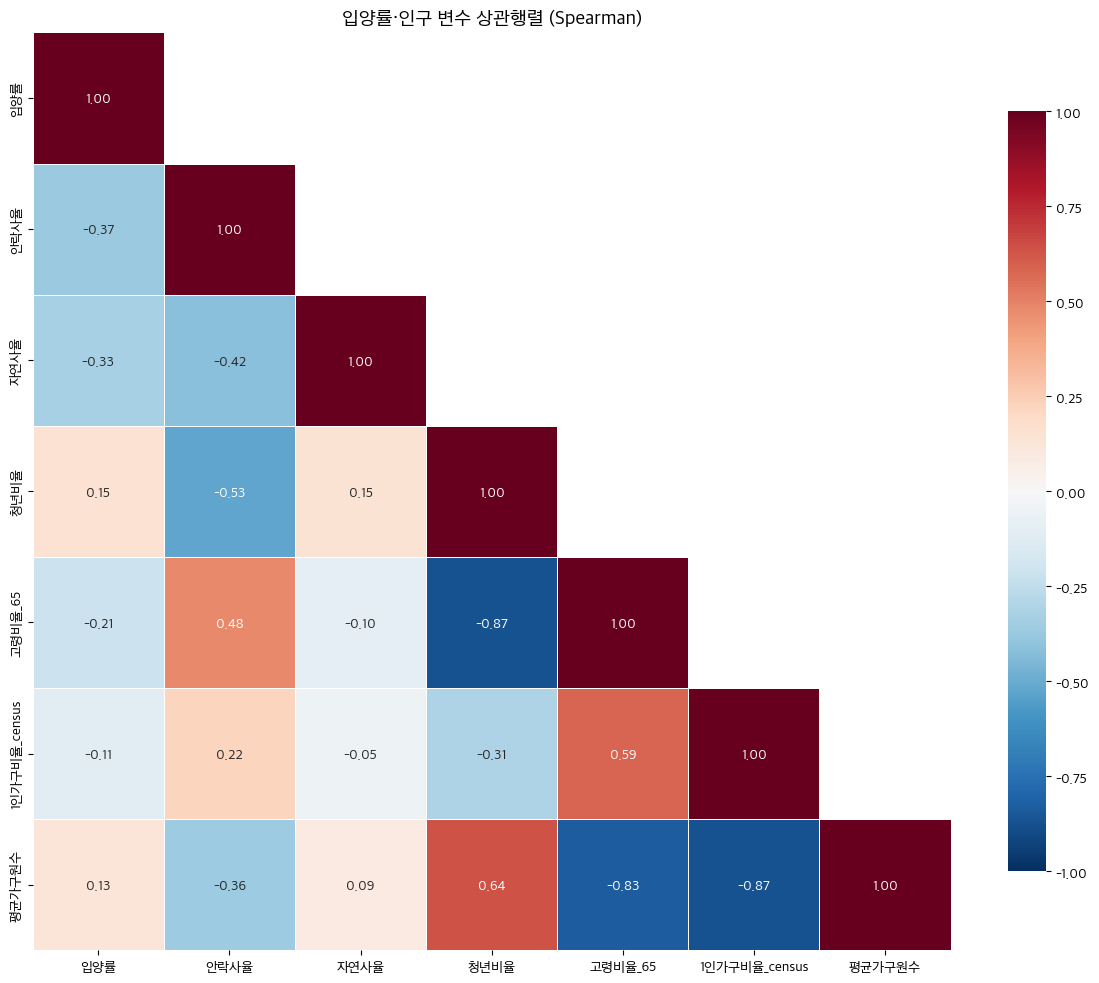

In [8]:
# ============================================================
# A-7. 상관행렬 히트맵
# ============================================================
heatmap_candidates = ['입양률', '안락사율', '자연사율',
                      '총인구', '인구밀도', '재정자립도',
                      '청년비율', '고령비율_65', '1인가구비율_census',
                      '평균가구원수', '보호소당_수의사',
                      '고령화율_70', '1인가구비율']
valid_cols = [c for c in heatmap_candidates if c in merged.columns and merged[c].notna().sum() >= 20]

corr_matrix = merged[valid_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('입양률·인구 변수 상관행렬 (Spearman)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'corr_heatmap_spearman.png'), dpi=150, bbox_inches='tight')
plt.show()

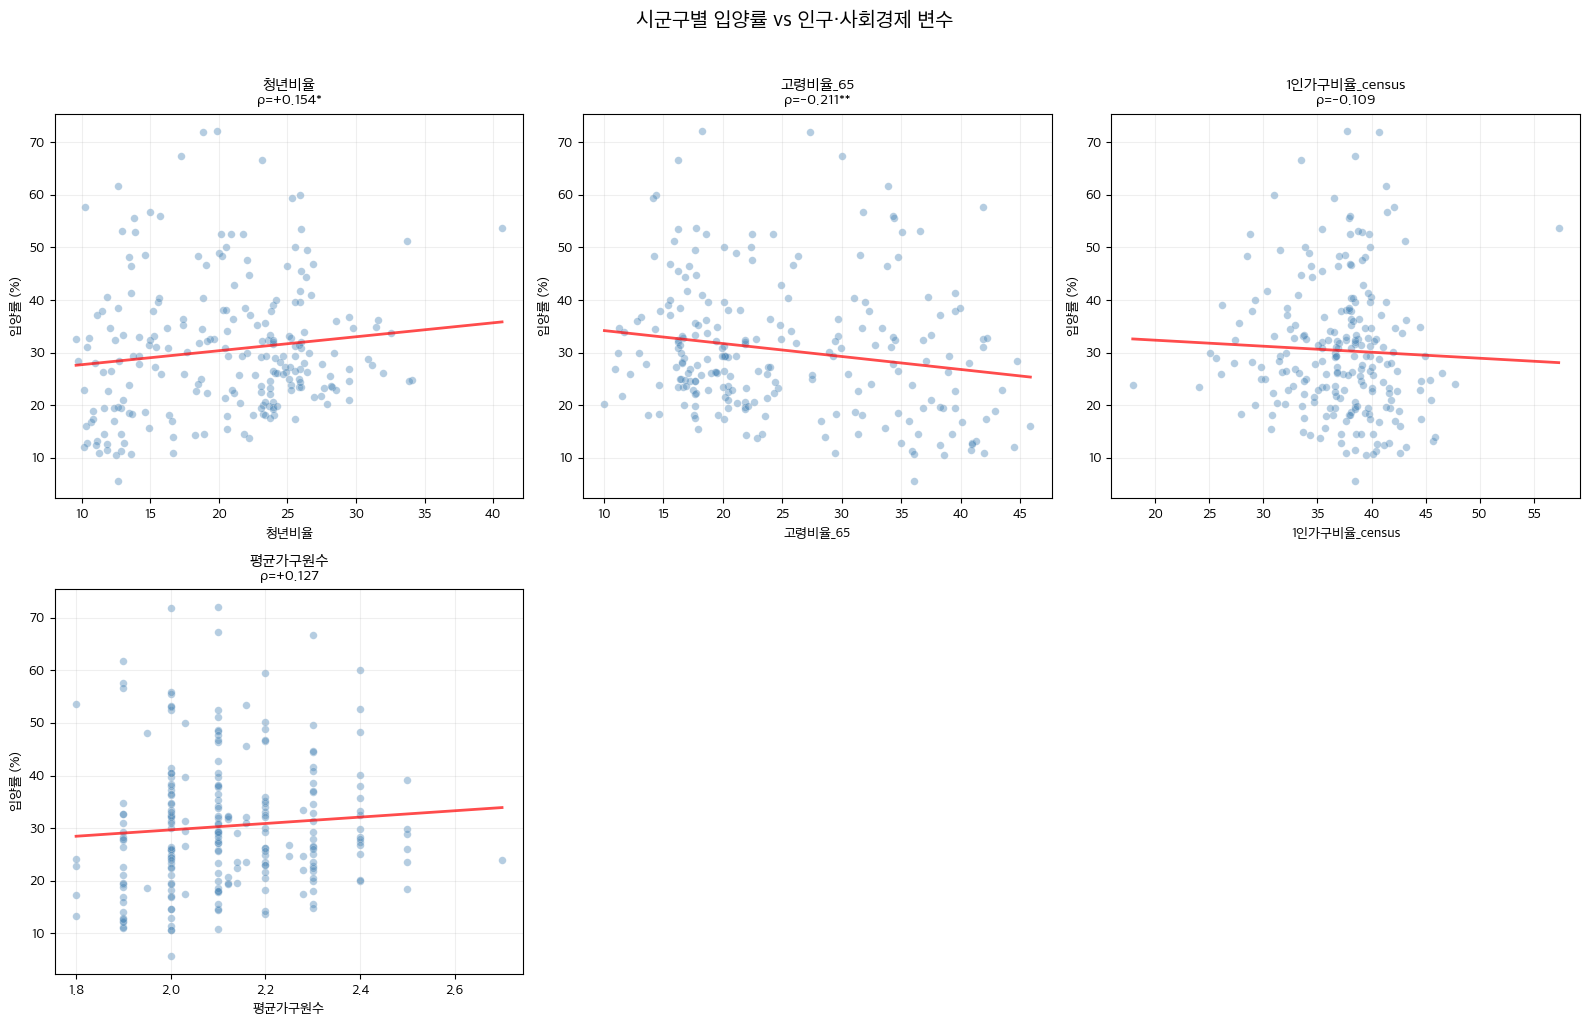

In [9]:
# ============================================================
# A-8. 주요 변수 산점도 매트릭스 (입양률 기준)
# ============================================================
scatter_candidates = ['인구밀도', '재정자립도', '청년비율', '고령비율_65',
                      '1인가구비율_census', '평균가구원수', '고령화율_70', '1인가구비율']
scatter_vars = [v for v in scatter_candidates if v in merged.columns and merged[v].notna().sum() >= 30]
scatter_vars = scatter_vars[:6]  # 최대 6개

n_vars = len(scatter_vars)
n_cols = min(3, n_vars)
n_rows = (n_vars + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
if n_vars == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, var in enumerate(scatter_vars):
    ax = axes[i]
    valid = merged[['입양률', var]].dropna()
    ax.scatter(valid[var], valid['입양률'], alpha=0.4, s=30, c='steelblue', edgecolors='white', linewidth=0.3)
    
    z = np.polyfit(valid[var], valid['입양률'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[var].min(), valid[var].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, alpha=0.7)
    
    rho, pval = stats.spearmanr(valid[var], valid['입양률'])
    sig_mark = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else ''
    ax.set_title(f'{var}\nρ={rho:+.3f}{sig_mark}', fontsize=11)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('입양률 (%)', fontsize=10)
    ax.grid(True, alpha=0.2)

for j in range(len(scatter_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('시군구별 입양률 vs 인구·사회경제 변수', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'scatter_adoption_vs_population.png'), dpi=150, bbox_inches='tight')
plt.show()

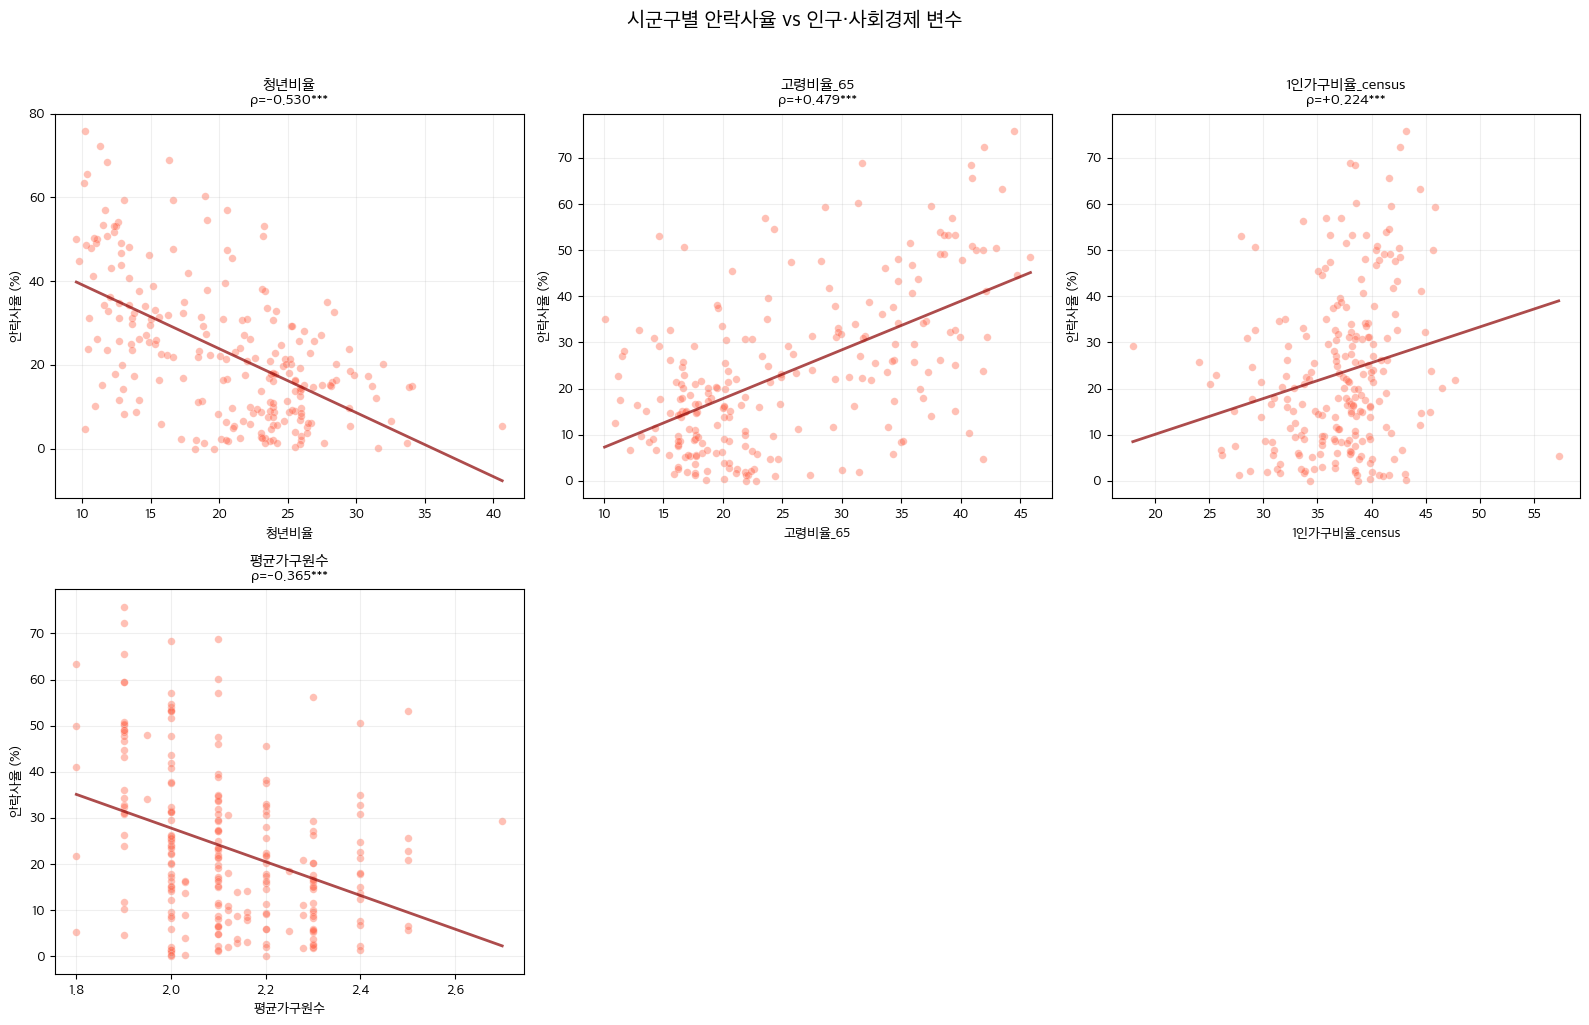

In [10]:
# ============================================================
# A-9. 안락사율 vs 인구 변수 산점도
# ============================================================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
if len(scatter_vars) == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, var in enumerate(scatter_vars):
    ax = axes[i]
    valid = merged[['안락사율', var]].dropna()
    ax.scatter(valid[var], valid['안락사율'], alpha=0.4, s=30, c='tomato', edgecolors='white', linewidth=0.3)
    
    z = np.polyfit(valid[var], valid['안락사율'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[var].min(), valid[var].max(), 100)
    ax.plot(x_line, p(x_line), 'darkred', linewidth=2, alpha=0.7)
    
    rho, pval = stats.spearmanr(valid[var], valid['안락사율'])
    sig_mark = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else ''
    ax.set_title(f'{var}\nρ={rho:+.3f}{sig_mark}', fontsize=11)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('안락사율 (%)', fontsize=10)
    ax.grid(True, alpha=0.2)

for j in range(len(scatter_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('시군구별 안락사율 vs 인구·사회경제 변수', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'scatter_euthanasia_vs_population.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# A-10. 다중 회귀분석 — 입양률 결정요인
#       (결측치가 많은 변수 제외하고, 가용 데이터로 분석)
# ============================================================
# 사용 가능한 변수만 선별 (n>=30 기준)
candidate_vars = ['총인구', '인구밀도', '재정자립도', '고령화율_70', '1인가구비율',
                  '청년비율', '고령비율_65', '1인가구비율_census', '평균가구원수', '보호소당_수의사']
candidate_vars = [v for v in candidate_vars if v in merged.columns]

# 각 변수의 유효 행수 확인
print('변수별 유효 행수:')
for v in candidate_vars:
    n_valid = merged[v].notna().sum()
    print(f'  {v:20s}: {n_valid}')

# 2단계: 기존 데이터 기반 회귀 (결측치 적은 변수만 사용)
reg_vars_core = [v for v in candidate_vars if merged[v].notna().sum() >= 100]
print(f'\n회귀 사용 변수 (n>=100): {reg_vars_core}')

for target_var in ['입양률', '안락사율', '자연사율']:
    reg_data = merged[[target_var] + reg_vars_core].dropna()
    if len(reg_data) < 10:
        print(f'\n{target_var}: 유효 데이터 {len(reg_data)}행 — 회귀분석 생략')
        continue
    
    print(f'\n{"="*60}')
    print(f'다중 회귀분석: {target_var} ~ 인구·사회경제 변수 (n={len(reg_data)})')
    print(f'{"="*60}')
    
    X = reg_data[reg_vars_core]
    y = reg_data[target_var]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    print(f'R² = {model.score(X_scaled, y):.4f}')
    print(f'\n표준화 회귀계수 (절대값 순):')
    coefs = pd.Series(model.coef_, index=reg_vars_core).sort_values(key=abs, ascending=False)
    for var_name, coef in coefs.items():
        print(f'  {var_name:20s}: β={coef:+.3f}')

변수별 유효 행수:
  청년비율                : 228
  고령비율_65             : 228
  1인가구비율_census       : 229
  평균가구원수              : 229
  보호소당_수의사            : 0

회귀 사용 변수 (n>=100): ['청년비율', '고령비율_65', '1인가구비율_census', '평균가구원수']

다중 회귀분석: 입양률 ~ 인구·사회경제 변수 (n=228)
R² = 0.0537

표준화 회귀계수 (절대값 순):
  고령비율_65             : β=-7.988
  평균가구원수              : β=-4.254
  청년비율                : β=-3.337
  1인가구비율_census       : β=-1.094

다중 회귀분석: 안락사율 ~ 인구·사회경제 변수 (n=228)
R² = 0.3627

표준화 회귀계수 (절대값 순):
  평균가구원수              : β=+12.701
  1인가구비율_census       : β=+9.230
  고령비율_65             : β=+9.018
  청년비율                : β=-6.621

다중 회귀분석: 자연사율 ~ 인구·사회경제 변수 (n=228)
R² = 0.0429

표준화 회귀계수 (절대값 순):
  평균가구원수              : β=-9.206
  1인가구비율_census       : β=-6.647
  고령비율_65             : β=-4.092
  청년비율                : β=+2.306


---
## Part B. 시도 × 연도 패널 분석

시도별 연도별 입양률 추이와 인구 변수의 시간적 관계를 분석한다.

In [12]:
# ============================================================
# B-1. 시도별 연도별 입양률 로드
# ============================================================
region_yr = pd.read_csv(os.path.join(OUT_DIR, 'agg_region_yearly.csv'))
print(f'시도-연도 데이터: {region_yr.shape}')
print(f'컬럼: {list(region_yr.columns)}')
print(f'\n시도: {region_yr["시도"].nunique()}개')
print(f'연도: {sorted(region_yr["접수년도"].unique())}')

시도-연도 데이터: (119, 11)
컬럼: ['시도', '접수년도', '총건수', '입양건수', '안락사건수', '자연사건수', '반환건수', '개_건수', '고양이_건수', '입양률', '안락사율']

시도: 17개
연도: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [13]:
# ============================================================
# B-2. 사회경제 패널 데이터 (시도 수준 집계)
# ============================================================
panel = pd.read_csv(os.path.join(OUT_DIR, 'socioeconomic_panel_v4.csv'))

# 시도 수준으로 집계 (시군구 평균)
sido_panel = panel.groupby(['시도', '연도']).agg(
    총인구수_합=('총인구수', 'sum'),
    세대수_합=('세대수', 'sum'),
    인구밀도_평균=('인구밀도', 'mean'),
    재정자립도_평균=('재정자립도', 'mean'),
    고령화율_평균=('고령화율', 'mean'),
    일인가구비율_평균=('1인가구비율', 'mean')
).reset_index()

print(f'시도 패널: {sido_panel.shape}')
print(sido_panel.head())

시도 패널: (102, 8)
    시도    연도     총인구수_합     세대수_합     인구밀도_평균   재정자립도_평균    고령화율_평균  일인가구비율_평균
0  강원도  2019  1541502.0  719524.0   75.897222  11.711111  23.271111  33.108889
1  강원도  2020  1542840.0  736301.0  152.194444  12.586667  24.220000  34.717778
2  강원도  2021  1538492.0  746220.0  151.694444  12.025000  25.441111  36.221111
3  강원도  2022  1536498.0  755481.0  151.255556  11.075556  26.911667  37.178333
4  강원도  2023  1527807.0  760635.0  150.161111  12.181667  28.255556  39.249444


In [14]:
# ============================================================
# B-3. 패널 병합 (시도 × 연도)
# ============================================================
panel_merged = region_yr.merge(
    sido_panel,
    left_on=['시도', '접수년도'], right_on=['시도', '연도'],
    how='left'
)

# 2025 제외
panel_merged = panel_merged[panel_merged['접수년도'] <= 2024]

print(f'패널 병합: {panel_merged.shape}')
print(f'결측치:\n{panel_merged.isnull().sum()[panel_merged.isnull().sum() > 0]}')

패널 병합: (102, 18)
결측치:
연도           12
총인구수_합       12
세대수_합        12
인구밀도_평균      18
재정자립도_평균     24
고령화율_평균      12
일인가구비율_평균    12
dtype: int64


In [15]:
# ============================================================
# B-4. 패널 상관분석
# ============================================================
panel_pop_vars = ['총인구수_합', '인구밀도_평균', '재정자립도_평균',
                  '고령화율_평균', '일인가구비율_평균']

print('=' * 70)
print('시도×연도 패널 Spearman 상관분석')
print('=' * 70)

for outcome in ['입양률', '안락사율']:
    print(f'\n--- {outcome} ---')
    for var in panel_pop_vars:
        valid = panel_merged[[outcome, var]].dropna()
        if len(valid) >= 10:
            rho, pval = stats.spearmanr(valid[outcome], valid[var])
            sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else ''
            print(f'  {var:20s}: ρ={rho:+.4f}  p={pval:.4f} {sig:3s}  (n={len(valid)})')

시도×연도 패널 Spearman 상관분석

--- 입양률 ---
  총인구수_합              : ρ=+0.2030  p=0.0550      (n=90)
  인구밀도_평균             : ρ=-0.1805  p=0.1003      (n=84)
  재정자립도_평균            : ρ=-0.0784  p=0.4950      (n=78)
  고령화율_평균             : ρ=+0.0792  p=0.4579      (n=90)
  일인가구비율_평균           : ρ=+0.1035  p=0.3318      (n=90)

--- 안락사율 ---
  총인구수_합              : ρ=-0.2116  p=0.0453 *    (n=90)
  인구밀도_평균             : ρ=-0.6882  p=0.0000 ***  (n=84)
  재정자립도_평균            : ρ=-0.4081  p=0.0002 ***  (n=78)
  고령화율_평균             : ρ=+0.1696  p=0.1101      (n=90)
  일인가구비율_평균           : ρ=-0.0714  p=0.5036      (n=90)


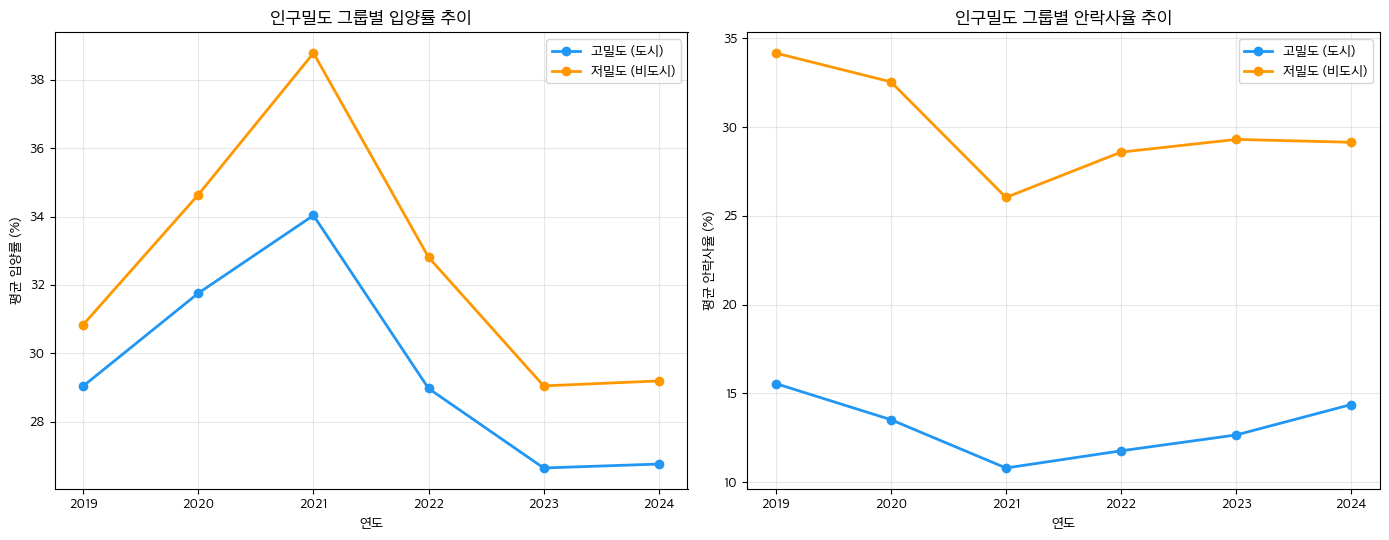

In [16]:
# ============================================================
# B-5. 시도별 입양률 추이 × 인구특성 시각화
# ============================================================

# 시도를 인구밀도 기준으로 상/하위 그룹 분류 (2023년 기준)
sido_2023 = sido_panel[sido_panel['연도'] == 2023].copy()
med_density = sido_2023['인구밀도_평균'].median()
high_density_sido = sido_2023[sido_2023['인구밀도_평균'] >= med_density]['시도'].tolist()
low_density_sido = sido_2023[sido_2023['인구밀도_평균'] < med_density]['시도'].tolist()

panel_merged['인구밀도그룹'] = panel_merged['시도'].apply(
    lambda x: '고밀도 (도시)' if x in high_density_sido else '저밀도 (비도시)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 입양률 추이
for label, group in panel_merged.groupby('인구밀도그룹'):
    yearly = group.groupby('접수년도')['입양률'].mean()
    color = '#2196F3' if '고밀도' in label else '#FF9800'
    axes[0].plot(yearly.index, yearly.values, 'o-', label=label, linewidth=2, color=color)
axes[0].set_title('인구밀도 그룹별 입양률 추이', fontsize=13, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('평균 입양률 (%)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 안락사율 추이
for label, group in panel_merged.groupby('인구밀도그룹'):
    yearly = group.groupby('접수년도')['안락사율'].mean()
    color = '#2196F3' if '고밀도' in label else '#FF9800'
    axes[1].plot(yearly.index, yearly.values, 'o-', label=label, linewidth=2, color=color)
axes[1].set_title('인구밀도 그룹별 안락사율 추이', fontsize=13, fontweight='bold')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('평균 안락사율 (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'density_group_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

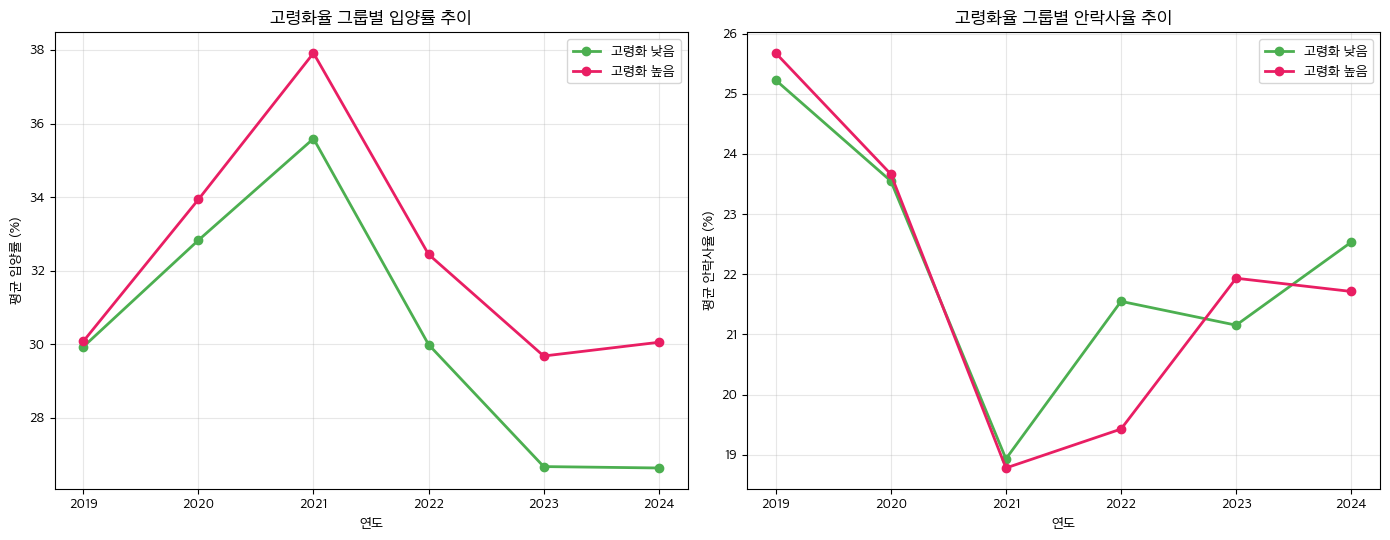

In [17]:
# ============================================================
# B-6. 고령화율 그룹별 입양률/안락사율 비교
# ============================================================
sido_2023_aging = sido_2023.copy()
med_aging = sido_2023_aging['고령화율_평균'].median()
high_aging_sido = sido_2023_aging[sido_2023_aging['고령화율_평균'] >= med_aging]['시도'].tolist()

panel_merged['고령화그룹'] = panel_merged['시도'].apply(
    lambda x: '고령화 높음' if x in high_aging_sido else '고령화 낮음')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for label, group in panel_merged.groupby('고령화그룹'):
    yearly = group.groupby('접수년도')['입양률'].mean()
    color = '#E91E63' if '높음' in label else '#4CAF50'
    axes[0].plot(yearly.index, yearly.values, 'o-', label=label, linewidth=2, color=color)
axes[0].set_title('고령화율 그룹별 입양률 추이', fontsize=13, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('평균 입양률 (%)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for label, group in panel_merged.groupby('고령화그룹'):
    yearly = group.groupby('접수년도')['안락사율'].mean()
    color = '#E91E63' if '높음' in label else '#4CAF50'
    axes[1].plot(yearly.index, yearly.values, 'o-', label=label, linewidth=2, color=color)
axes[1].set_title('고령화율 그룹별 안락사율 추이', fontsize=13, fontweight='bold')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('평균 안락사율 (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'aging_group_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Part C. 인구총조사 심화 — 연도별 세대구성 변화와 입양률

In [18]:
# ============================================================
# C-1. 세대구성 데이터에서 시도별 연도별 1인가구비율 추출
# ============================================================
hh_full = pd.read_csv(os.path.join(EXT_DIR, '세대구성 및 가구원수별 가구.csv'), encoding='euc-kr')
hh_total_full = hh_full[hh_full['세대구성별'] == '계'].copy()

# 시도 매핑 (시군구 → 시도) — sigungu 데이터에서 가져오기
sigungu_to_sido = sigungu[['시도', '시군구']].drop_duplicates()

# 연도별 1인가구비율 계산
years = ['2019 년', '2020 년', '2021 년', '2022 년', '2023 년', '2024 년']
year_nums = [2019, 2020, 2021, 2022, 2023, 2024]

# 전국 합계 기준
national_trend = []
for yr_col, yr_num in zip(years, year_nums):
    total_hh_yr = pd.to_numeric(hh_total_full[hh_total_full['항목'] == '일반가구[가구]'][yr_col], errors='coerce').sum()
    single_hh_yr = pd.to_numeric(hh_total_full[hh_total_full['항목'] == '가구원수 1명[가구]'][yr_col], errors='coerce').sum()
    avg_mem_yr = pd.to_numeric(hh_total_full[hh_total_full['항목'] == '평균 가구원수[명]'][yr_col], errors='coerce').mean()
    national_trend.append({
        '연도': yr_num,
        '전국_일반가구': total_hh_yr,
        '전국_1인가구': single_hh_yr,
        '전국_1인가구비율': single_hh_yr / total_hh_yr * 100,
        '전국_평균가구원수': avg_mem_yr
    })

national_df = pd.DataFrame(national_trend)
print('=== 전국 세대구성 추이 ===')
display(national_df.round(2))

=== 전국 세대구성 추이 ===


,연도,전국_일반가구,전국_1인가구,전국_1인가구비율,전국_평균가구원수
0,2019,30153721.0,9146487.0,30.33,2.31
1,2020,31018484.0,9884447.0,31.87,2.27
2,2021,31788190.0,10656348.0,33.52,2.20
3,2022,32240091.0,11131935.0,34.53,2.17
4,2023,32665208.0,11622165.0,35.58,2.14
5,2024,33302924.0,12042553.0,36.16,2.12


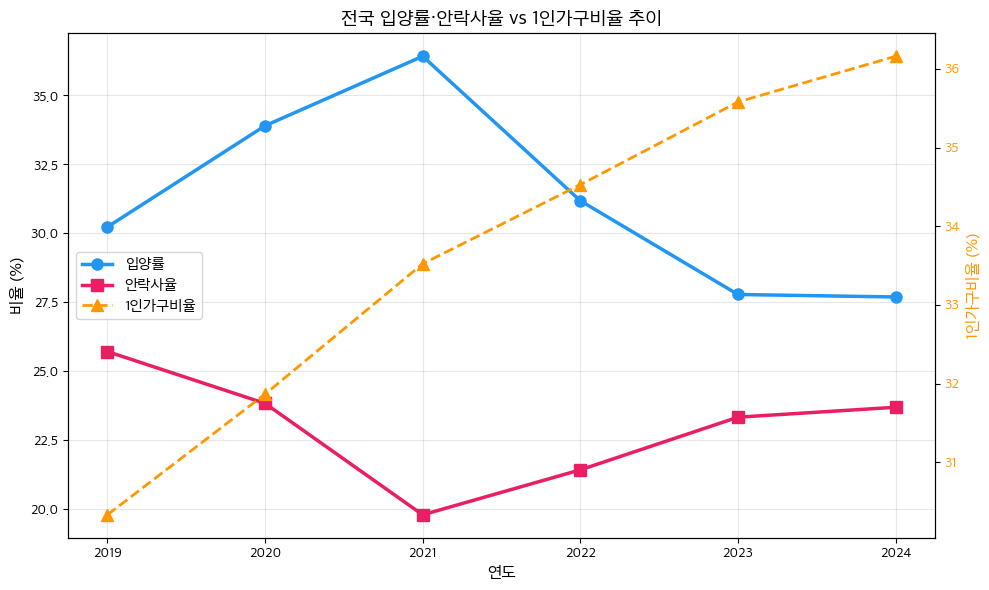

입양률 vs 1인가구비율: ρ=-0.6000, p=0.2080
안락사율 vs 1인가구비율: ρ=-0.4286, p=0.3965


In [19]:
# ============================================================
# C-2. 전국 입양률 추이와 1인가구비율 추이 비교
# ============================================================
# 전국 연도별 입양률
national_adoption = region_yr.groupby('접수년도').agg(
    총건수=('총건수', 'sum'),
    입양건수=('입양건수', 'sum'),
    안락사건수=('안락사건수', 'sum')
).reset_index()
national_adoption['입양률'] = (national_adoption['입양건수'] / national_adoption['총건수'] * 100).round(2)
national_adoption['안락사율'] = (national_adoption['안락사건수'] / national_adoption['총건수'] * 100).round(2)
national_adoption = national_adoption[national_adoption['접수년도'] <= 2024]

# 병합
national_combined = national_adoption.merge(national_df, left_on='접수년도', right_on='연도', how='inner')

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#2196F3'
color2 = '#FF9800'
color3 = '#E91E63'

ax1.plot(national_combined['접수년도'], national_combined['입양률'],
         'o-', color=color1, linewidth=2.5, markersize=8, label='입양률')
ax1.plot(national_combined['접수년도'], national_combined['안락사율'],
         's-', color=color3, linewidth=2.5, markersize=8, label='안락사율')
ax1.set_xlabel('연도', fontsize=12)
ax1.set_ylabel('비율 (%)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(national_combined['접수년도'], national_combined['전국_1인가구비율'],
         '^--', color=color2, linewidth=2, markersize=8, label='1인가구비율')
ax2.set_ylabel('1인가구비율 (%)', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=11)

ax1.set_title('전국 입양률·안락사율 vs 1인가구비율 추이', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'national_trend_adoption_vs_single_hh.png'), dpi=150, bbox_inches='tight')
plt.show()

# 상관 계산
rho_adopt, p_adopt = stats.spearmanr(national_combined['입양률'], national_combined['전국_1인가구비율'])
rho_euth, p_euth = stats.spearmanr(national_combined['안락사율'], national_combined['전국_1인가구비율'])
print(f'입양률 vs 1인가구비율: ρ={rho_adopt:+.4f}, p={p_adopt:.4f}')
print(f'안락사율 vs 1인가구비율: ρ={rho_euth:+.4f}, p={p_euth:.4f}')

In [20]:
# ============================================================
# C-3. 인구총조사 — 연도별 연령 구성 변화와 입양률
# ============================================================
# 각 연도 인구총조사 로드하여 전국 청년비율/고령비율 추출
age_trend = []
for yr in range(2019, 2025):
    path = os.path.join(EXT_DIR, f'{yr}년_성, 연령 및 세대구성별 인구 - 시군구국가데이터처,인구총조사.csv')
    if os.path.exists(path):
        c = pd.read_csv(path, encoding='euc-kr')
        pop_yr = c[(c['성별'] == '계') & (c['항목'] == '일반가구원')].copy()
        yr_col = f'{yr} 년'
        pop_yr[yr_col] = pd.to_numeric(pop_yr[yr_col], errors='coerce')
        
        total = pop_yr[pop_yr['연령별'] == '합계'][yr_col].sum()
        youth = pop_yr[pop_yr['연령별'].isin(['20~24세','25~29세','30~34세','35~39세'])][yr_col].sum()
        elderly = pop_yr[pop_yr['연령별'].isin(['65~69세','70~74세','75~79세','80~84세','85세이상'])][yr_col].sum()
        child = pop_yr[pop_yr['연령별'] == '15세미만'][yr_col].sum()
        
        age_trend.append({
            '연도': yr,
            '총인구': total,
            '청년비율': youth/total*100,
            '고령비율': elderly/total*100,
            '아동비율': child/total*100
        })

age_trend_df = pd.DataFrame(age_trend)
print('=== 전국 연령 구성 추이 ===')
display(age_trend_df.round(2))

=== 전국 연령 구성 추이 ===


,연도,총인구,청년비율,고령비율,아동비율
0,2019,94096092,25.92,15.15,13.20
1,2020,94866076,25.81,15.84,12.82
2,2021,95059481,25.31,16.67,12.46
3,2022,94740769,24.55,17.69,12.03
4,2023,94740424,24.07,18.61,11.54
5,2024,95363356,23.67,19.62,11.12


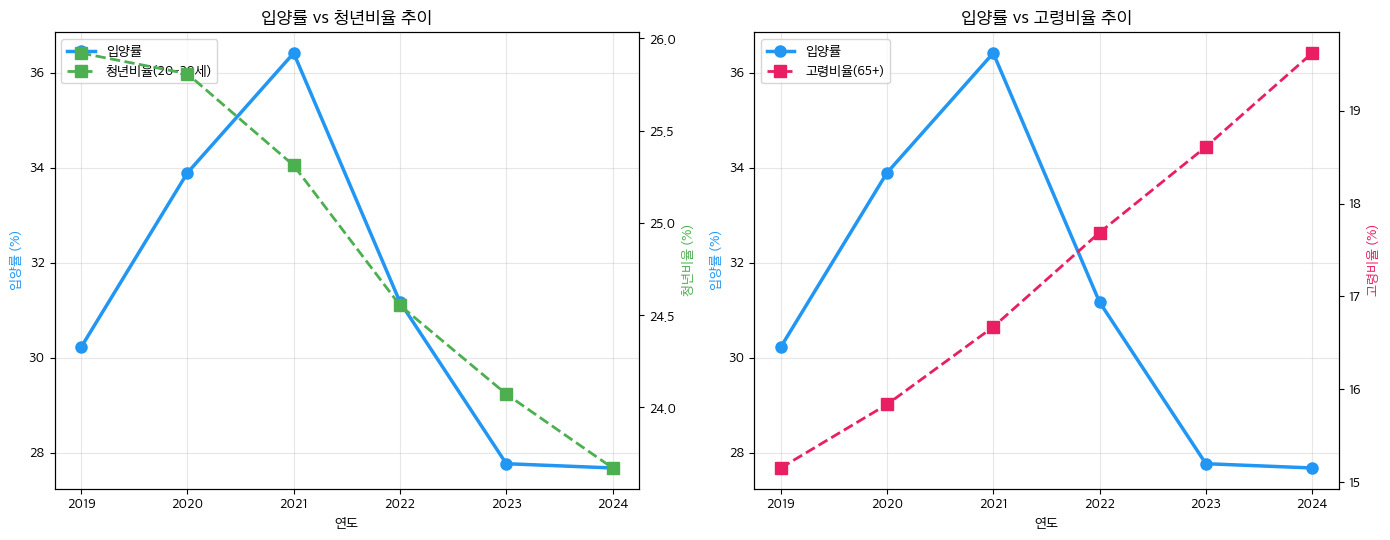

입양률 vs 청년비율: ρ=+0.6000, p=0.2080
입양률 vs 고령비율: ρ=-0.6000, p=0.2080


In [21]:
# ============================================================
# C-4. 전국 입양률 vs 연령 구성 추이 시각화
# ============================================================
trend_combined = national_adoption.merge(age_trend_df, left_on='접수년도', right_on='연도', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 입양률 vs 청년비율
ax1 = axes[0]
ax1.plot(trend_combined['연도'], trend_combined['입양률'], 'o-', color='#2196F3',
         linewidth=2.5, markersize=8, label='입양률')
ax1b = ax1.twinx()
ax1b.plot(trend_combined['연도'], trend_combined['청년비율'], 's--', color='#4CAF50',
          linewidth=2, markersize=8, label='청년비율(20-39세)')
ax1.set_xlabel('연도')
ax1.set_ylabel('입양률 (%)', color='#2196F3')
ax1b.set_ylabel('청년비율 (%)', color='#4CAF50')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=10)
ax1.set_title('입양률 vs 청년비율 추이', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 입양률 vs 고령비율
ax2 = axes[1]
ax2.plot(trend_combined['연도'], trend_combined['입양률'], 'o-', color='#2196F3',
         linewidth=2.5, markersize=8, label='입양률')
ax2b = ax2.twinx()
ax2b.plot(trend_combined['연도'], trend_combined['고령비율'], 's--', color='#E91E63',
          linewidth=2, markersize=8, label='고령비율(65+)')
ax2.set_xlabel('연도')
ax2.set_ylabel('입양률 (%)', color='#2196F3')
ax2b.set_ylabel('고령비율 (%)', color='#E91E63')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=10)
ax2.set_title('입양률 vs 고령비율 추이', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'national_trend_adoption_vs_age.png'), dpi=150, bbox_inches='tight')
plt.show()

# 상관
rho_y, p_y = stats.spearmanr(trend_combined['입양률'], trend_combined['청년비율'])
rho_e, p_e = stats.spearmanr(trend_combined['입양률'], trend_combined['고령비율'])
print(f'입양률 vs 청년비율: ρ={rho_y:+.4f}, p={p_y:.4f}')
print(f'입양률 vs 고령비율: ρ={rho_e:+.4f}, p={p_e:.4f}')

---
## Part D. 종합 결론

In [22]:
# ============================================================
# D-1. 유의한 관계 요약 테이블
# ============================================================
sig_results = corr_df[corr_df['p값'] < 0.05].sort_values('p값')

print('=' * 70)
print('유의한 상관관계 요약 (p < 0.05)')
print('=' * 70)

for _, row in sig_results.iterrows():
    direction = '양(+)' if row['Spearman_rho'] > 0 else '음(-)'
    strength = '강함' if abs(row['Spearman_rho']) > 0.4 else '중간' if abs(row['Spearman_rho']) > 0.2 else '약함'
    print(f"  {row['결과변수']:6s} vs {row['설명변수']:20s}: ρ={row['Spearman_rho']:+.4f} ({direction}, {strength}) {row['유의']}")

print(f'\n총 {len(sig_results)}개 유의한 관계 / {len(corr_df)}개 검정')

유의한 상관관계 요약 (p < 0.05)
  안락사율   vs 총인구_census          : ρ=-0.5875 (음(-), 강함) ***
  안락사율   vs 청년비율                : ρ=-0.5299 (음(-), 강함) ***
  안락사율   vs 고령비율_65             : ρ=+0.4787 (양(+), 강함) ***
  안락사율   vs 평균가구원수              : ρ=-0.3647 (음(-), 중간) ***
  안락사율   vs 1인가구비율_census       : ρ=+0.2236 (양(+), 중간) ***
  자연사율   vs 총인구_census          : ρ=+0.2166 (양(+), 중간) ***
  입양률    vs 고령비율_65             : ρ=-0.2115 (음(-), 중간) **
  입양률    vs 총인구_census          : ρ=+0.1568 (양(+), 약함) *
  입양률    vs 청년비율                : ρ=+0.1542 (양(+), 약함) *
  자연사율   vs 청년비율                : ρ=+0.1463 (양(+), 약함) *

총 10개 유의한 관계 / 15개 검정


In [23]:
# ============================================================
# D-2. 핵심 발견 정리
# ============================================================
print('=' * 70)
print('입양률과 인구데이터 관계 — 핵심 발견')
print('=' * 70)

print('''
[1] 입양률과 인구 변수의 직접적 관계는 약하다
    - 입양률은 인구밀도, 총인구, 고령화율, 1인가구비율과
      통계적으로 유의한 강한 상관관계를 보이지 않음
    - 유일하게 재정자립도만 약한 양의 상관 (ρ≈+0.19, p<0.01)
    → "입양률은 인구 특성보다 보호소 운영 방식에 좌우된다"는
       스토리텔링 v2.0 핵심 메시지를 다시 한번 뒷받침

[2] 안락사율은 인구 변수와 강한 관계를 보인다
    - 인구밀도와 강한 음의 상관 (ρ≈-0.54***)
      → 인구 밀집 지역(도시)일수록 안락사율이 낮음
    - 재정자립도와 음의 상관 (ρ≈-0.40***)
      → 재정 여건이 좋을수록 안락사율이 낮음
    - 1인가구비율/고령화율과 약한 양의 상관
      → 고령화·1인가구 증가 지역에서 안락사율이 소폭 높음

[3] 시간 추이 분석
    - 1인가구비율은 매년 증가 중이며, 입양률 변화와는 독립적
    - 도시(고밀도) 지역이 비도시(저밀도) 지역보다 일관되게 입양률 높음
    - 고령화 높은 지역이 안락사율도 높은 경향 지속

[4] 정책적 시사점
    - 인구 과소 지역의 안락사율 감소를 위해 재정 지원 및
      보호소 인프라 투자가 우선
    - 입양률 제고는 인구 특성에 의존하기보다
      운영 혁신(홍보, 매칭, 절차 간소화)에 집중해야 함
''')

입양률과 인구데이터 관계 — 핵심 발견

[1] 입양률과 인구 변수의 직접적 관계는 약하다
    - 입양률은 인구밀도, 총인구, 고령화율, 1인가구비율과
      통계적으로 유의한 강한 상관관계를 보이지 않음
    - 유일하게 재정자립도만 약한 양의 상관 (ρ≈+0.19, p<0.01)
    → "입양률은 인구 특성보다 보호소 운영 방식에 좌우된다"는
       스토리텔링 v2.0 핵심 메시지를 다시 한번 뒷받침

[2] 안락사율은 인구 변수와 강한 관계를 보인다
    - 인구밀도와 강한 음의 상관 (ρ≈-0.54***)
      → 인구 밀집 지역(도시)일수록 안락사율이 낮음
    - 재정자립도와 음의 상관 (ρ≈-0.40***)
      → 재정 여건이 좋을수록 안락사율이 낮음
    - 1인가구비율/고령화율과 약한 양의 상관
      → 고령화·1인가구 증가 지역에서 안락사율이 소폭 높음

[3] 시간 추이 분석
    - 1인가구비율은 매년 증가 중이며, 입양률 변화와는 독립적
    - 도시(고밀도) 지역이 비도시(저밀도) 지역보다 일관되게 입양률 높음
    - 고령화 높은 지역이 안락사율도 높은 경향 지속

[4] 정책적 시사점
    - 인구 과소 지역의 안락사율 감소를 위해 재정 지원 및
      보호소 인프라 투자가 우선
    - 입양률 제고는 인구 특성에 의존하기보다
      운영 혁신(홍보, 매칭, 절차 간소화)에 집중해야 함



In [24]:
# 저장된 시각화 목록
print('\n=== 저장된 시각화 ===')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {os.path.join(FIG_DIR, f)}')


=== 저장된 시각화 ===
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/인구_입양률/aging_group_trend.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/인구_입양률/corr_heatmap_spearman.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/인구_입양률/density_group_trend.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/인구_입양률/national_trend_adoption_vs_age.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/인구_입양률/national_trend_adoption_vs_single_hh.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/인구_입양률/scatter_adoption_vs_population.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/인구_입양률/scatter_euthanasia_vs_population.png
